# 6D-VHQ Analysis Notebook 4: Imagery Ability and Questionnaire Validity

## File Setup

In [9]:
## libraries

import pandas as pd
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
### filepaths ###

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")

## Question Keys

In [11]:
### question key ###

# get and read excel file
vhq_key_path = os.path.join(qKeys_path, "VHQ_question_key.xlsx")
question_key = pd.read_excel(vhq_key_path)
question_key['q_col']   = question_key['question'].apply(lambda n: f"Q{n}")

rev_list = question_key["reversed"].to_list()

print(question_key.head())

   question  dimension  reversed  expected       name  \
0         1          1         0        -1  geometric   
1         2          1         0        -1  geometric   
2         3          1         0        -1  geometric   
3         4          2         0        -1   semantic   
4         5          2         0        -1   semantic   

                                            text_old  \
0  I saw shapes, lines, dots, or other geometric ...   
1  I saw geometrical patterns, similar to honeyco...   
2  I saw patterns, such as repeating shapes or co...   
3  I saw things which looked like living beings, ...   
4  My visual experience contained elements that r...   

                                                text q_col  
0  1. I saw shapes, lines, dots, or other geometr...    Q1  
1  2. I saw geometrical patterns, similar to hone...    Q2  
2  3. I saw patterns, such as repeating shapes or...    Q3  
3  4. I saw things which looked like living being...    Q4  
4  5. My visual

In [12]:
### Dimension names ###

### with infrequency dimension
dimension_names = list(dict.fromkeys(question_key["name"]))
 
## without infrequency dimension
dimension_labels = dimension_names[:-1]


## Data Import

In [13]:
## data import

vhq_rec_df_items = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_items.csv"))
print("VHQ REC Items")
print(vhq_rec_df_items.head())

vhq_rec_df_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_dims.csv"))
print("VHQ REC Dimensions")
print(vhq_rec_df_dims.head())

psiq_df = pd.read_csv(os.path.join(tables_path, "df_psiq_rec_dims.csv"))
print("PSIQ Dimensions")
print(psiq_df.head())




VHQ REC Items
          ResponseId  Q01  Q02  Q03  Q04  Q05  Q06  Q07  Q08  Q09  ...  Q12  \
0  R_2XhSm3rVuTDh2XT    1    1    2    5    5    5    5    5    5  ...    4   
1  R_82J66rTAKMAkEMO    2    1    2    1    4    1    3    4    3  ...    5   
2  R_80OjC1M5y1RxlPM    5    5    5    5    4    4    2    2    2  ...    3   
3  R_8rdBxiZHeShoPvf    5    5    5    1    2    1    3    4    3  ...    2   
4  R_2rH7YSrGIo4VOqn    5    5    5    5    5    1    5    5    5  ...    5   

   Q13  Q14  Q15  Q16  Q17  Q18  Q19  Q20  Q21  
0    2    2    1    2    3    3    1    5  NaN  
1    1    1    3    1    2    1    1    5  NaN  
2    2    2    1    3    2    4    1    5  NaN  
3    3    4    2    5    3    4    1    5  NaN  
4    1    5    1    3    1    5    1    5  NaN  

[5 rows x 22 columns]
VHQ REC Dimensions
          ResponseId  geometric  semantic    detail  vividness   entropy  \
0  R_2XhSm3rVuTDh2XT   1.333333  5.000000  5.000000   4.333333  1.666667   
1  R_82J66rTAKMAkEMO   

## Measuring internal consistency vs imagery

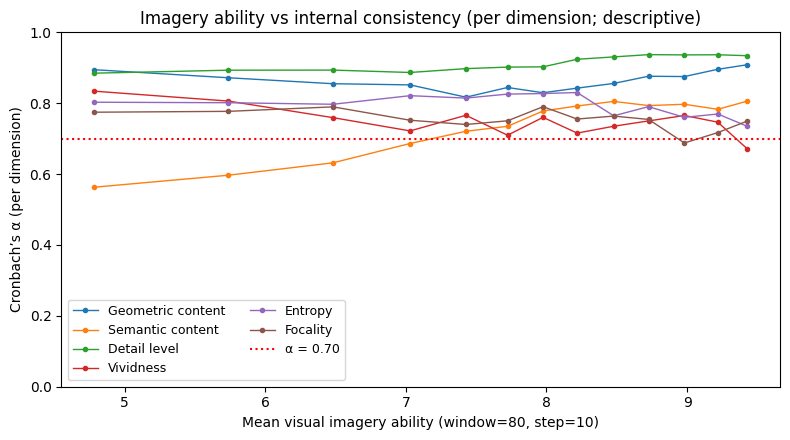

,mean_vision,n_in_window,alpha_Geometric content,alpha_Semantic content,alpha_Detail level,alpha_Vividness,alpha_Entropy,alpha_Focality
0,4.782500,80,0.894577,0.562924,0.884739,0.834044,0.802778,0.774589
1,5.737500,80,0.871841,0.596774,0.893151,0.806047,0.801395,0.777031
2,6.482500,80,0.855007,0.631810,0.893457,0.759284,0.797036,0.789694
3,7.030000,80,0.851708,0.686290,0.886699,0.721892,0.821250,0.751988
4,7.427500,80,0.817007,0.720811,0.897593,0.765884,0.814456,0.739942
5,7.723333,80,0.844371,0.734810,0.901859,0.709694,0.825709,0.750365
6,7.975833,80,0.829525,0.778042,0.902659,0.760107,0.827263,0.790175
7,8.218333,80,0.842592,0.792176,0.924003,0.715651,0.830109,0.755358
8,8.478333,80,0.855796,0.805070,0.930630,0.735059,0.764460,0.763676
9,8.725833,80,0.876110,0.793284,0.937077,0.750000,0.790309,0.754275


In [14]:


def cronbach_alpha(items_df: pd.DataFrame) -> float:
    """Compute Cronbach's alpha for a DataFrame of items (columns)."""
    items_df = items_df.dropna(axis=0, how='any')
    k = items_df.shape[1]
    if k < 2 or len(items_df) < 3:
        return np.nan

    item_vars = items_df.var(axis=0, ddof=1)
    total_score = items_df.sum(axis=1)
    total_var = total_score.var(ddof=1)

    if total_var == 0 or np.isnan(total_var):
        return np.nan

    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


# ----------------------------
# Parameters
# ----------------------------
window_size = 80
step_size = 10
require_complete_all_items = True 

# ----------------------------
# 1. Merge the two dataframes on ResponseId
# ----------------------------
df_all = vhq_rec_df_items.merge(
    psiq_df[['ResponseId', 'vision']],
    on='ResponseId',
    how='inner'
).dropna(subset=['vision'])

# Ensure numeric
question_cols = [f'Q{str(i).zfill(2)}' for i in range(1, 19)]
for c in question_cols:
    df_all[c] = pd.to_numeric(df_all[c], errors='coerce')
df_all['vision'] = pd.to_numeric(df_all['vision'], errors='coerce')

df_all = df_all.dropna(subset=['vision'])

# ----------------------------
# 2. Define the VHQ item columns and dimensions
# ----------------------------
dimension_names = [
    "Geometric content",
    "Semantic content",
    "Detail level",
    "Vividness",
    "Entropy",
    "Focality",
]

dimensions = [
    ['Q01', 'Q02', 'Q03'],
    ['Q04', 'Q05', 'Q06'],
    ['Q07', 'Q08', 'Q09'],
    ['Q10', 'Q11', 'Q12'],
    ['Q13', 'Q14', 'Q15'],
    ['Q16', 'Q17', 'Q18'],
]

# ----------------------------
# 3. Prepare sorted participants
# ----------------------------
if require_complete_all_items:
    df_clean = df_all.dropna(subset=question_cols).reset_index(drop=True)
else:
    # Keep participants with partial item missingness; alphas will be computed
    # using complete cases within each 3-item dimension per window.
    df_clean = df_all.reset_index(drop=True)

df_sorted = df_clean.sort_values('vision').reset_index(drop=True)

# ----------------------------
# 4. Sliding-window computation (per-dimension alpha)
# ----------------------------
mean_visions = []
n_in_window_used = []
alphas_by_dim = {name: [] for name in dimension_names}

max_start = len(df_sorted) - window_size
for start in range(0, max_start + 1, step_size):
    window = df_sorted.iloc[start:start + window_size]

    mean_visions.append(window['vision'].mean())
    n_in_window_used.append(len(window))

    for name, dims in zip(dimension_names, dimensions):
        a = cronbach_alpha(window[dims])
        alphas_by_dim[name].append(a)

sliding_df = pd.DataFrame({
    "mean_vision": mean_visions,
    "n_in_window": n_in_window_used,
    **{f"alpha_{name}": vals for name, vals in alphas_by_dim.items()},
})

# ----------------------------
# 5. Plot: imagery ability vs internal consistency (per dimension)
# ----------------------------
plt.figure(figsize=(8, 4.5))
x = sliding_df["mean_vision"].to_numpy(dtype=float)

for name in dimension_names:
    y = sliding_df[f"alpha_{name}"].to_numpy(dtype=float)
    plt.plot(x, y, marker="o", markersize=3, linewidth=1, label=name)

plt.ylim(0, 1)
plt.xlabel(f"Mean visual imagery ability (window={window_size}, step={step_size})")
plt.ylabel("Cronbach’s α (per dimension)")
plt.title("Imagery ability vs internal consistency (per dimension; descriptive)")
plt.axhline(0.7, linestyle=":", color="red", label="α = 0.70")
plt.legend(loc="lower left", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

sliding_df